<a href="https://colab.research.google.com/github/tayyba678/-Assignment_Week_07_2023-CS-130_B/blob/master/BRISC_Week2_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import os

os.listdir()

['.config', 'archive.zip', 'sample_data']

In [6]:
zip_path = "/content/archive.zip"
extract_path = "/content/brisc_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [7]:
os.listdir(extract_path)

['brisc2025']

In [8]:
for root, dirs, files in os.walk(extract_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

/content/brisc_dataset
Folders: ['brisc2025']
Files: []
--------------------------------------------------
/content/brisc_dataset/brisc2025
Folders: ['segmentation_task', 'classification_task']
Files: ['manifest.csv', 'manifest.json.sha256', 'README.md', 'manifest.csv.sha256', 'manifest.json']
--------------------------------------------------
/content/brisc_dataset/brisc2025/segmentation_task
Folders: ['test', 'train']
Files: []
--------------------------------------------------
/content/brisc_dataset/brisc2025/segmentation_task/test
Folders: ['masks', 'images']
Files: []
--------------------------------------------------
/content/brisc_dataset/brisc2025/segmentation_task/test/masks
Folders: []
Files: ['brisc2025_test_00176_gl_sa_t1.png', 'brisc2025_test_00826_pi_co_t1.png', 'brisc2025_test_00547_me_sa_t1.png', 'brisc2025_test_00972_pi_sa_t1.png', 'brisc2025_test_00485_me_sa_t1.png']
--------------------------------------------------
/content/brisc_dataset/brisc2025/segmentation_task/

In [9]:
dataset_root = "/content/brisc_dataset/brisc2025"

os.listdir(dataset_root)

['manifest.csv',
 'segmentation_task',
 'manifest.json.sha256',
 'README.md',
 'manifest.csv.sha256',
 'manifest.json',
 'classification_task']

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


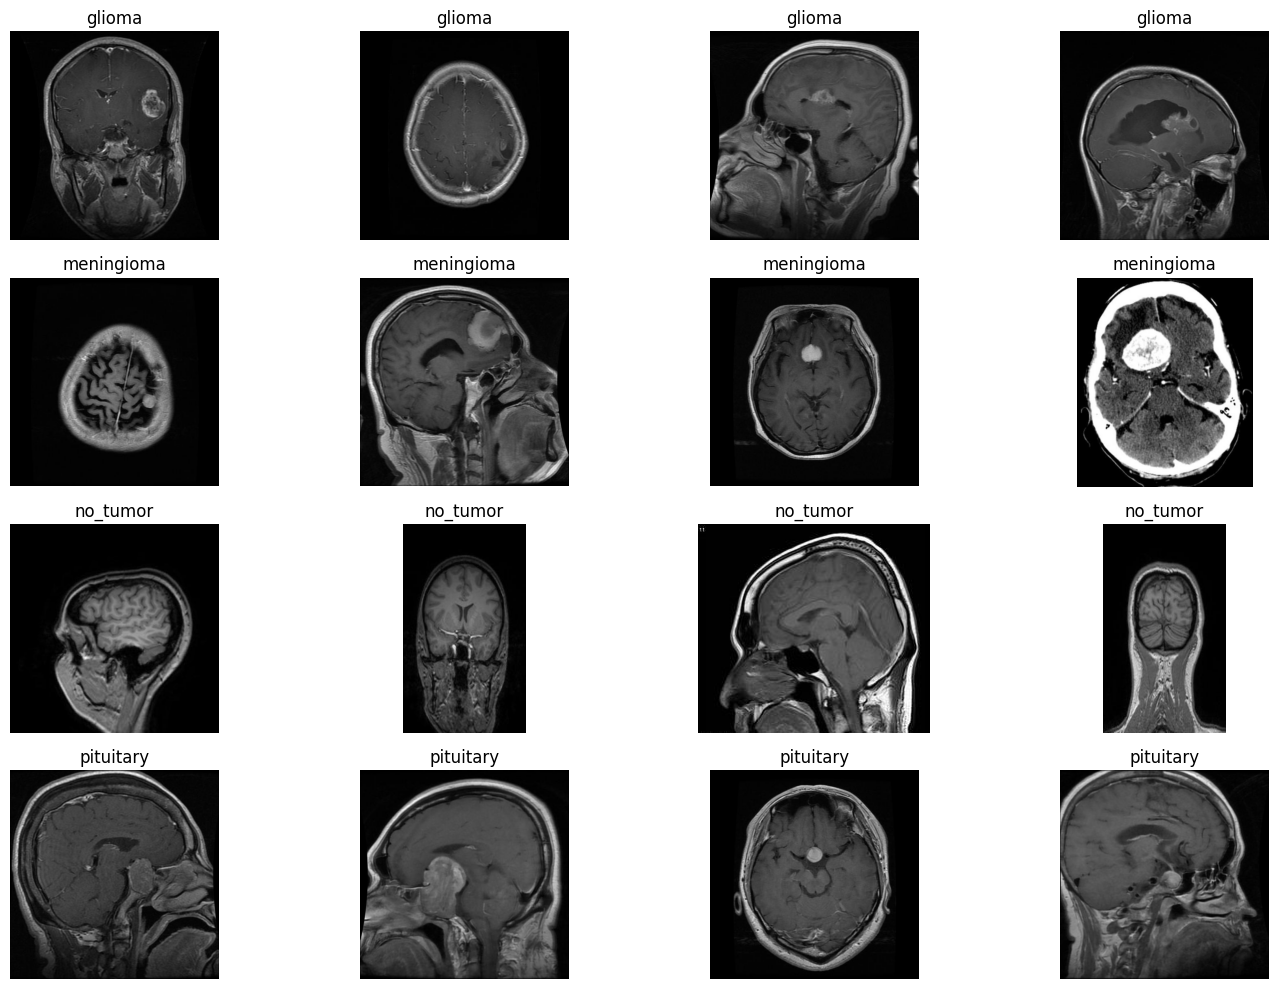

In [10]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Train path
train_path = "/content/brisc_dataset/brisc2025/classification_task/train"

# Class names
classes = sorted(os.listdir(train_path))

print("Classes:", classes)

# Create figure
plt.figure(figsize=(15,10))

count = 1

for category in classes:

    category_path = os.path.join(train_path, category)

    images = os.listdir(category_path)

    # Pick 4 random images
    sample_images = random.sample(images, 4)

    for img_name in sample_images:

        img_path = os.path.join(category_path, img_name)

        img = cv2.imread(img_path)

        # Convert BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 4, count)
        plt.imshow(img)
        plt.title(category)
        plt.axis("off")

        count += 1

plt.tight_layout()
plt.show()

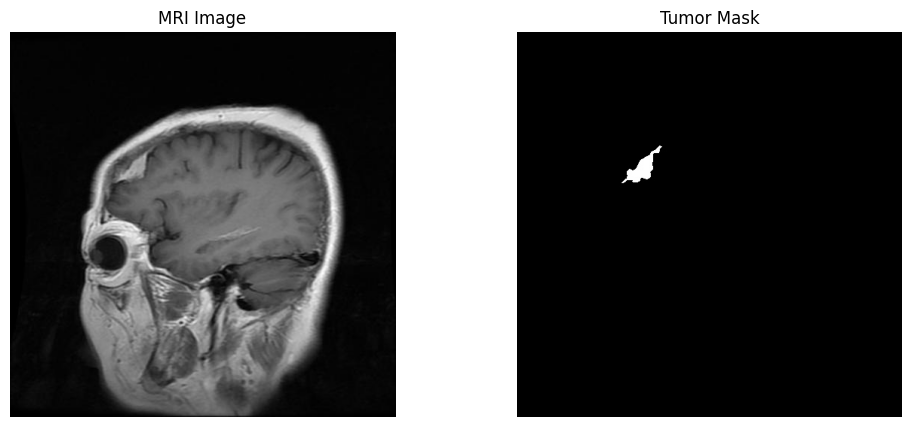

Image: brisc2025_train_02087_me_sa_t1.jpg
Mask : brisc2025_train_02087_me_sa_t1.png


In [11]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Paths
image_path = "/content/brisc_dataset/brisc2025/segmentation_task/train/images"
mask_path = "/content/brisc_dataset/brisc2025/segmentation_task/train/masks"

# Random sample
sample_image = random.choice(os.listdir(image_path))

# Corresponding mask name
mask_name = sample_image.replace(".jpg", ".png")

# Full paths
img_full_path = os.path.join(image_path, sample_image)
mask_full_path = os.path.join(mask_path, mask_name)

# Read image and mask
image = cv2.imread(img_full_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)

# Display
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()

print("Image:", sample_image)
print("Mask :", mask_name)

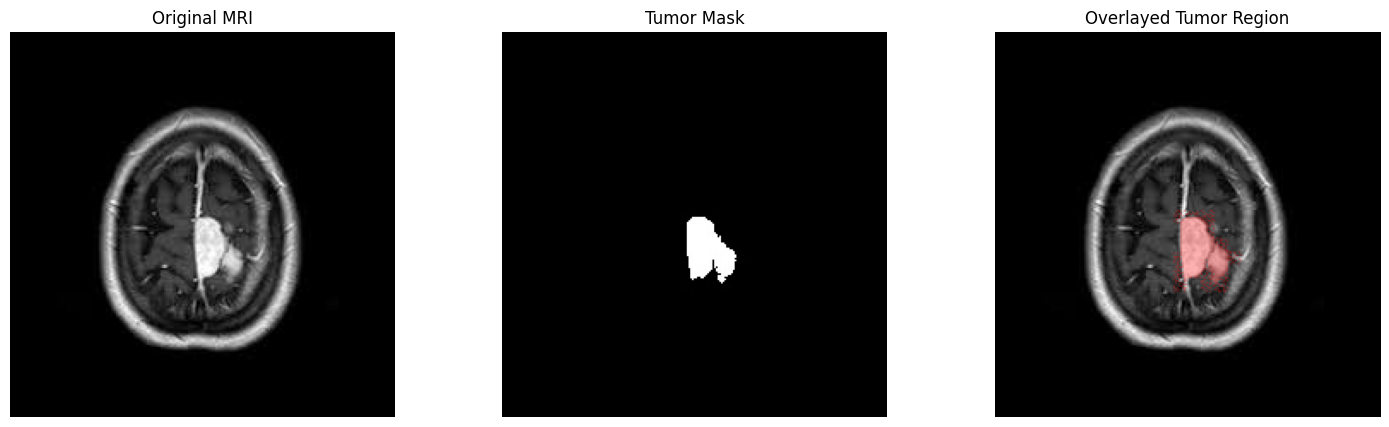

Image: brisc2025_train_01300_me_ax_t1.jpg


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

# Paths
image_path = "/content/brisc_dataset/brisc2025/segmentation_task/train/images"
mask_path = "/content/brisc_dataset/brisc2025/segmentation_task/train/masks"

# Random image
sample_image = random.choice(os.listdir(image_path))
mask_name = sample_image.replace(".jpg", ".png")

# Read image
img = cv2.imread(os.path.join(image_path, sample_image))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Read mask
mask = cv2.imread(
    os.path.join(mask_path, mask_name),
    cv2.IMREAD_GRAYSCALE
)

# Convert mask to binary
binary_mask = mask > 0

# Create overlay
overlay = img_rgb.copy()

# Red highlight on tumor
overlay[binary_mask] = [255, 0, 0]

# Blend image + mask
blended = cv2.addWeighted(
    img_rgb,
    0.7,
    overlay,
    0.3,
    0
)

# Show results
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blended)
plt.title("Overlayed Tumor Region")
plt.axis("off")

plt.show()

print("Image:", sample_image)

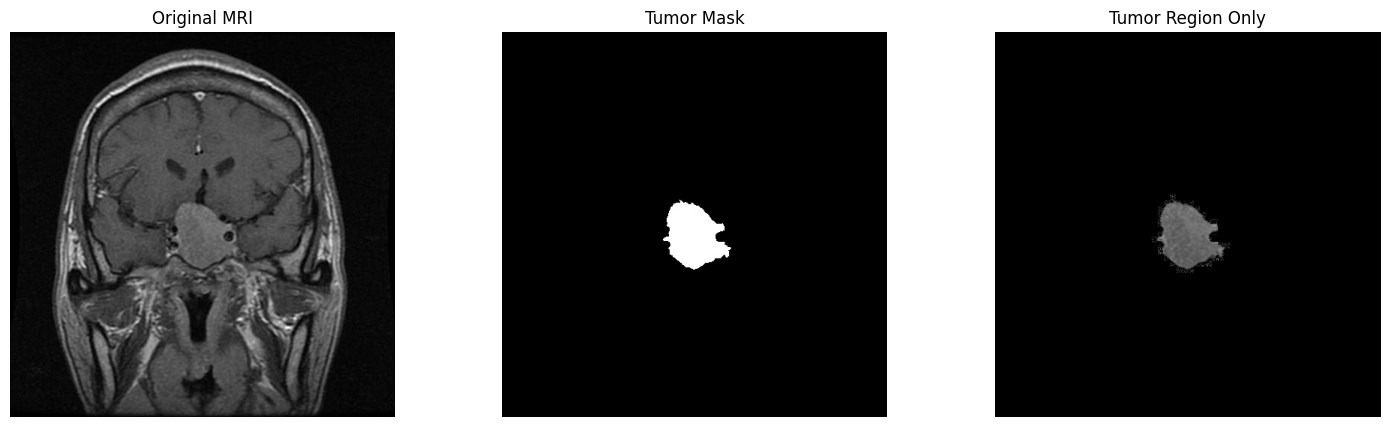

Image: brisc2025_train_04027_pi_co_t1.jpg


In [13]:
import os
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np

# Paths
image_path = "/content/brisc_dataset/brisc2025/segmentation_task/train/images"
mask_path = "/content/brisc_dataset/brisc2025/segmentation_task/train/masks"

# Pick random image
sample_image = random.choice(os.listdir(image_path))
mask_name = sample_image.replace(".jpg", ".png")

# Read image
img = cv2.imread(os.path.join(image_path, sample_image))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Read mask
mask = cv2.imread(
    os.path.join(mask_path, mask_name),
    cv2.IMREAD_GRAYSCALE
)

# Binary mask
binary_mask = mask > 0

# Extract tumor only
tumor_only = np.zeros_like(img_rgb)
tumor_only[binary_mask] = img_rgb[binary_mask]

# Plot
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(tumor_only)
plt.title("Tumor Region Only")
plt.axis("off")

plt.show()

print("Image:", sample_image)

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "/content/brisc_dataset/brisc2025/classification_task/train"
test_dir = "/content/brisc_dataset/brisc2025/classification_task/test"

# Preprocessing + augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Train data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Test data
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

# Load pretrained base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
img_size = (224, 224)
batch_size = 32
train_path = "/content/brisc_dataset/brisc2025/classification_task/train"
test_path = "/content/brisc_dataset/brisc2025/classification_task/test"

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,   # normalize images
    validation_split=0.2  # 20% data for validation
)

In [19]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 4002 images belonging to 4 classes.


In [20]:
val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 998 images belonging to 4 classes.


In [21]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1000 images belonging to 4 classes.


In [22]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 62s 328ms/step - accuracy: 0.8021 - loss: 0.5067 - val_accuracy: 0.8196 - val_loss: 0.5618
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.8966 - loss: 0.2834 - val_accuracy: 0.8236 - val_loss: 0.5944
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9108 - loss: 0.2316 - val_accuracy: 0.8377 - val_loss: 0.5546
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.9328 - loss: 0.1820 - val_accuracy: 0.8307 - val_loss: 0.5934
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.9420 - loss: 0.1626 - val_accuracy: 0.8357 - val_loss: 0.6247
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.9498 - loss: 0.1387 - val_accuracy: 0.8327 - val_loss: 0.5561
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.9530 - loss: 0.1273 - val_accuracy: 0.8377 - val_loss: 0.6372
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9648 - loss: 0.1017 -

In [23]:
test_loss, test_acc = model.evaluate(test_generator)
print(test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.8680 - loss: 0.6042
0.8679999709129333


In [32]:
from google.colab import drive

In [31]:
print("Saving model and history to local Colab filesystem (temporary storage).")
model.save("brisc_brain_tumor_model.h5")
import pickle

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("Model saved as 'brisc_brain_tumor_model.h5'")
print("Training history saved as 'training_history.pkl'")
print("You can download these files by clicking on the folder icon on the left panel, navigating to the file, and right-clicking to download.")

Saving model and history to local Colab filesystem (temporary storage).
Model saved as 'brisc_brain_tumor_model.h5'
Training history saved as 'training_history.pkl'
You can download these files by clicking on the folder icon on the left panel, navigating to the file, and right-clicking to download.


In [35]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.8680 - loss: 0.6042
Test Accuracy: 0.8679999709129333
Test Loss: 0.6041809320449829


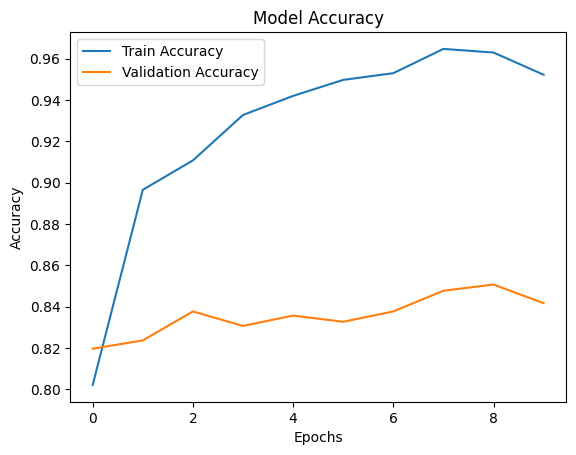

In [36]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

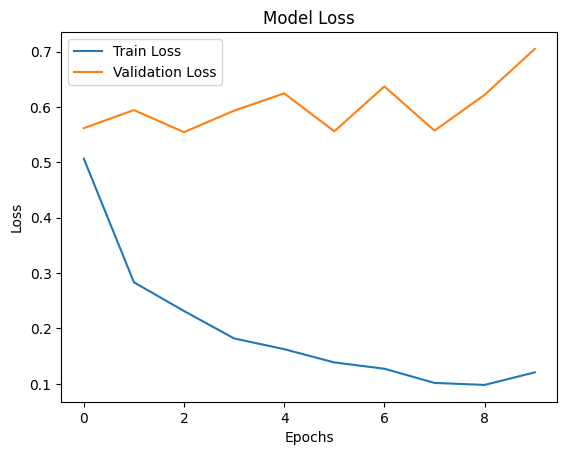

In [37]:
# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [39]:
model.save("brain_tumor_model.h5")

In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_path = "/content/brisc_dataset/brisc2025/classification_task/test"

img_size = (224, 224)
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)
test_labels = test_data.classes
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 1000 images belonging to 4 classes.


In [45]:
import numpy as np

y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step


In [46]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(test_labels, y_pred_classes))
print(confusion_matrix(test_labels, y_pred_classes))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       254
           1       0.85      0.71      0.77       306
           2       0.70      0.98      0.81       140
           3       0.94      0.96      0.95       300

    accuracy                           0.87      1000
   macro avg       0.86      0.88      0.86      1000
weighted avg       0.88      0.87      0.87      1000

[[227  24   1   2]
 [ 16 217  59  14]
 [  0   2 137   1]
 [  1  12   0 287]]


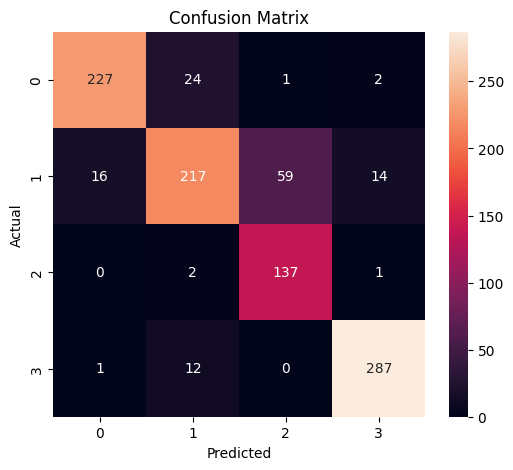

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [48]:
import pandas as pd

results = pd.DataFrame({
    "True_Label": test_labels,
    "Predicted_Label": y_pred_classes
})

results.to_csv("predictions.csv", index=False)